In [5]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from PIL import Image
import torch
import os
from torchvision import transforms
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

In [6]:
#Check the device compatibility

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Usando dispositivo:", device)

Usando dispositivo: mps


# Load the models

In [7]:
#Load the Simple Model (Just CNN and clasificator whitout the new Clinical Vector)
model_path = "Models/Model_Exec_711_Epoch_150_cpu_portable_full.pt"

values = torch.load(model_path, map_location="cpu", weights_only=False)
simple_model = values["modelo"]

simple_model = simple_model.to(device)
simple_model.eval()

print("Modelo simple cargado correctamente")

Modelo simple cargado correctamente


In [8]:
print(simple_model)

CNN(
  (extraction): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): AvgPool2d(kernel_size=2, stride=2, padding=0)
    (4): Conv2d(8, 8, kernel_size=(9, 9), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU(inplace=True)
    (10): Conv2d(16, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(144, 128, kernel_size=(7, 7), stride=(1, 1)

In [9]:

full_model = torch.export.load("Models/DentalDeepGA_transfer_model.pt2")
print("Modelo .pt2 cargado correctamente")


Modelo .pt2 cargado correctamente


/Users/mauricio/Documents/Ecuela-UV/Semestre-8/Servicio/DeepGA/.venv/lib/python3.13/site-packages/torch/export/pt2_archive/_package.py:790: UserWarning: The given buffer is not writable, and PyTorch does not support non-writable tensors. This means you can write to the underlying (supposedly non-writable) buffer using the tensor. You may want to copy the buffer to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:1592.)
  tensor = torch.frombuffer(


In [10]:
print(full_model.graph_signature)


# inputs
p_embedding_extractor_features_0_0_weight: PARAMETER target='embedding_extractor.features.0.0.weight'
p_embedding_extractor_features_0_0_bias: PARAMETER target='embedding_extractor.features.0.0.bias'
p_embedding_extractor_features_0_1_weight: PARAMETER target='embedding_extractor.features.0.1.weight'
p_embedding_extractor_features_0_1_bias: PARAMETER target='embedding_extractor.features.0.1.bias'
p_embedding_extractor_features_1_0_weight: PARAMETER target='embedding_extractor.features.1.0.weight'
p_embedding_extractor_features_1_0_bias: PARAMETER target='embedding_extractor.features.1.0.bias'
p_embedding_extractor_features_1_1_weight: PARAMETER target='embedding_extractor.features.1.1.weight'
p_embedding_extractor_features_1_1_bias: PARAMETER target='embedding_extractor.features.1.1.bias'
p_embedding_extractor_features_2_0_weight: PARAMETER target='embedding_extractor.features.2.0.weight'
p_embedding_extractor_features_2_0_bias: PARAMETER target='embedding_extractor.features.

# Test the simple Model

In [11]:
#Data loader

class FolderImageDataset(Dataset):
    def __init__(self, root_dir, class_to_idx, transform=None):
        self.root_dir = root_dir
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.samples = []

        valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

        for class_name, class_idx in class_to_idx.items():
            class_dir = os.path.join(root_dir, class_name)

            if not os.path.isdir(class_dir):
                print(f"Advertencia: no existe la carpeta {class_dir}")
                continue

            for fname in sorted(os.listdir(class_dir)):
                if fname.lower().endswith(valid_ext):
                    img_path = os.path.join(class_dir, fname)
                    self.samples.append((img_path, class_idx, class_name, fname))

        self.targets = [s[1] for s in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, class_name, fname = self.samples[idx]

        image = Image.open(img_path).convert("L") 

        if self.transform is not None:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.long)

        return image, label

In [12]:
#Image transformations

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

In [13]:
#Create the clases and the mapping

root_dir = "DataSet/radiografia_dataset_original"

class_names = sorted([
    d for d in os.listdir(root_dir)
    if os.path.isdir(os.path.join(root_dir, d))
])

class_to_idx = {cls_name: i for i, cls_name in enumerate(class_names)}

print(class_to_idx)

{'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente tratado': 2, 'Pulpa Normal': 3, 'Pulpitis irreversible asintomatica': 4, 'Pulpitis irreversible sintomatica': 5, 'Pulpitis reversible': 6}


In [14]:
#Load the images

folder_ds = FolderImageDataset(
    root_dir=root_dir,
    class_to_idx=class_to_idx,
    transform=transform,
)

from torch.utils.data import DataLoader

folder_loader = DataLoader(
    folder_ds,
    batch_size=32,
    shuffle=False,
    num_workers=0,
)

print("Total de imágenes encontradas:", len(folder_ds))

Total de imágenes encontradas: 366


In [15]:
@torch.no_grad()
def evaluate_image_model(model, loader, device, idx_to_class):
    model.eval()

    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels_sorted = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels_sorted]

    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
    }

In [16]:
#Show results

idx_to_class = {v: k for k, v in class_to_idx.items()}

results_old = evaluate_image_model(
    model=simple_model,
    loader=folder_loader,
    device=device,
    idx_to_class=idx_to_class,
)

print("=== Modelo anterior sobre dataset por carpetas ===")
print(f"Accuracy           : {results_old['accuracy']:.4f}")
print(f"Precision macro    : {results_old['precision_macro']:.4f}")
print(f"Recall macro       : {results_old['recall_macro']:.4f}")
print(f"F1 macro           : {results_old['f1_macro']:.4f}")
print(f"Precision weighted : {results_old['precision_weighted']:.4f}")
print(f"Recall weighted    : {results_old['recall_weighted']:.4f}")
print(f"F1 weighted        : {results_old['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results_old["classification_report"])

print("\nConfusion matrix:\n")
print(results_old["confusion_matrix"])

=== Modelo anterior sobre dataset por carpetas ===
Accuracy           : 0.3388
Precision macro    : 0.1658
Recall macro       : 0.2220
F1 macro           : 0.1666
Precision weighted : 0.2354
Recall weighted    : 0.3388
F1 weighted        : 0.2477

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.32      0.69      0.43       100
              Previamente iniciado       0.00      0.00      0.00        25
               Previamente tratado       0.00      0.00      0.00        43
                      Pulpa Normal       0.43      0.73      0.54        62
Pulpitis irreversible asintomatica       0.17      0.02      0.03        56
 Pulpitis irreversible sintomatica       0.25      0.12      0.16        75
               Pulpitis reversible       0.00      0.00      0.00         5

                          accuracy                           0.34       366
                         macro avg       0

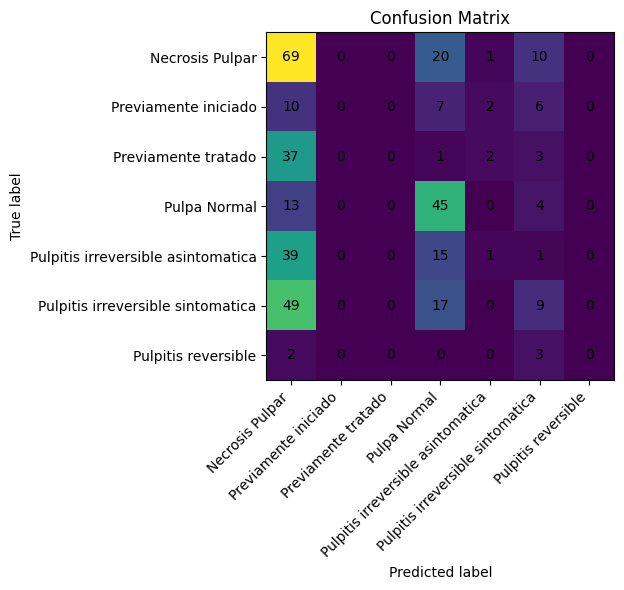

In [17]:
#Show confusion matrix

def plot_confusion_matrix(cm, idx_to_class):
    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    plt.figure(figsize=(8, 6))
    plt.imshow(cm)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.yticks(range(len(labels)), labels)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

    
plot_confusion_matrix(results_old["confusion_matrix"], idx_to_class)

# Test the full Model

In [18]:
# Load the clinical data from the CSV
df = pd.read_csv("DataSet/dataset_maestro.csv")

# Mapping clases
class_to_idx = {
    "Necrosis Pulpar": 0,
    "Previamente iniciado": 1,
    "Previamente Tratado": 2,
    "Pulpa Normal": 3,
    "Pulpitis Irreversible Asintomática": 4,
    "Pulpitis Irreversible Sintomática": 5,
    "Pulpitis Reversible": 6,
}

idx_to_class = {v: k for k, v in class_to_idx.items()}

def normalize_image_key(external_id):
    external_id = str(external_id).strip()
    prefix = "radiografia_dataset_original/"
    if external_id.startswith(prefix):
        return external_id[len(prefix):]
    return external_id

def build_clinical_vector(dx_periapical, sensibilidad, percusion, movilidad, palpacion):
    dx_periapical = str(dx_periapical).strip()
    sensibilidad = str(sensibilidad).strip().lower()
    percusion = str(percusion).strip().lower()
    movilidad = str(movilidad).strip()
    palpacion = str(palpacion).strip().lower()

    dx_map = {
        "Periodontitis apical asintomática": [1, 0, 0, 0, 0],
        "Absceso apical crónico":            [0, 1, 0, 0, 0],
        "Periodontitis apical sintomática":  [0, 0, 1, 0, 0],
        "Tejidos apicales normales":         [0, 0, 0, 1, 0],
        "Absceso apical agudo":              [0, 0, 0, 0, 1],
    }

    bin_map = {
        "positiva": 1.0,
        "positivo": 1.0,
        "negativa": 0.0,
        "negativo": 0.0,
    }

    movilidad_map = {
        "No valorable": [0, 0, 0],
        "1":            [1, 0, 0],
        "2":            [0, 1, 0],
        "3":            [0, 0, 1],
    }

    vector = (
        dx_map[dx_periapical]
        + [bin_map[sensibilidad]]
        + [bin_map[percusion]]
        + movilidad_map[movilidad]
        + [bin_map[palpacion]]
    )

    return torch.tensor(vector, dtype=torch.float32)

samples = []
errors = []

for idx, row in df.iterrows():
    try:
        image_key = normalize_image_key(row["external_id"])

        clinical_vector = build_clinical_vector(
            dx_periapical=row["Dx Periapical"],
            sensibilidad=row["Sensibilidad"],
            percusion=row["Percusión"],
            movilidad=row["Movilidad"],
            palpacion=row["Palpación"],
        )

        if row["Clase"] not in class_to_idx:
            raise KeyError(f"Clase no válida: {row['Clase']}")

        label = class_to_idx[row["Clase"]]

        samples.append({
            "image_key": image_key,               
            "clinical_vector": clinical_vector,   
            "label": label,                       
        })

    except Exception as e:
        errors.append((idx, str(e)))

print("Samples válidos:", len(samples))
print("Errores:", len(errors))

Samples válidos: 365
Errores: 0


In [19]:
#Data loader for the full model

root_dir = "DataSet/radiografia_dataset_original"

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

class FullMultimodalFolderDataset(Dataset):
    def __init__(self, samples, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.valid_ext = [".jpg", ".jpeg", ".png", ".JPG", ".JPEG", ".PNG"]

        self.samples = []
        self.missing = []

        for sample in samples:
            image_key = sample["image_key"]

            try:
                img_path = self._resolve_image_path(image_key)
                sample_copy = dict(sample)
                sample_copy["img_path"] = img_path
                self.samples.append(sample_copy)
            except Exception as e:
                self.missing.append({
                    "image_key": image_key,
                    "label": sample["label"],
                    "error": str(e),
                })

        self.targets = [s["label"] for s in self.samples]

    def _resolve_image_path(self, image_key):
        direct_path = os.path.join(self.root_dir, image_key)
        if os.path.exists(direct_path):
            return direct_path

        base, ext = os.path.splitext(image_key)

        if ext:
            folder = os.path.dirname(base)
            stem = os.path.basename(base)
        else:
            folder = os.path.dirname(image_key)
            stem = os.path.basename(image_key)

        folder_path = os.path.join(self.root_dir, folder)

        for candidate_ext in self.valid_ext:
            candidate = os.path.join(folder_path, stem + candidate_ext)
            if os.path.exists(candidate):
                return candidate

        if os.path.isdir(folder_path):
            files = os.listdir(folder_path)
            similar = [f for f in files if os.path.splitext(f)[0] == stem]
            if similar:
                return os.path.join(folder_path, similar[0])

        raise FileNotFoundError(f"No se encontró imagen para: {image_key}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        img_path = sample["img_path"]
        clinical = sample["clinical_vector"]
        label = torch.tensor(sample["label"], dtype=torch.long)

        image = Image.open(img_path).convert("L")

        if self.transform is not None:
            image = self.transform(image)

        return image, clinical, label

In [20]:
all_multi_ds = FullMultimodalFolderDataset(
    samples=samples,
    root_dir=root_dir,
    transform=transform,
)

all_multi_loader = DataLoader(
    all_multi_ds,
    batch_size=1,
    shuffle=False,
    num_workers=0,
)

print("Total de muestras válidas en loader:", len(all_multi_ds))
print("Total de imágenes faltantes:", len(all_multi_ds.missing))

Total de muestras válidas en loader: 364
Total de imágenes faltantes: 1


In [21]:
@torch.no_grad()
def evaluate_full_model(model, loader, device, idx_to_class):

    y_true = []
    y_pred = []

    for images, clinical, labels in loader:
        images = images.to(device)
        clinical = clinical.to(device)
        labels = labels.to(device)

        logits = model(images, clinical)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)

    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )

    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )

    labels_sorted = sorted(idx_to_class.keys())
    target_names = [idx_to_class[i] for i in labels_sorted]

    cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)

    report = classification_report(
        y_true,
        y_pred,
        labels=labels_sorted,
        target_names=target_names,
        zero_division=0,
    )

    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "recall_macro": recall_macro,
        "f1_macro": f1_macro,
        "precision_weighted": precision_weighted,
        "recall_weighted": recall_weighted,
        "f1_weighted": f1_weighted,
        "confusion_matrix": cm,
        "classification_report": report,
    }

=== Evaluación del modelo nuevo sobre TODO el dataset ===
Accuracy           : 0.8846
Precision macro    : 0.8958
Recall macro       : 0.8287
F1 macro           : 0.8543
Precision weighted : 0.8853
Recall weighted    : 0.8846
F1 weighted        : 0.8834

Classification report:

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.87      0.92      0.89       100
              Previamente iniciado       0.79      0.76      0.78        25
               Previamente Tratado       0.95      0.84      0.89        43
                      Pulpa Normal       0.97      0.98      0.98        61
Pulpitis Irreversible Asintomática       0.81      0.77      0.79        56
 Pulpitis Irreversible Sintomática       0.88      0.93      0.91        74
               Pulpitis Reversible       1.00      0.60      0.75         5

                          accuracy                           0.88       364
                         macro avg 

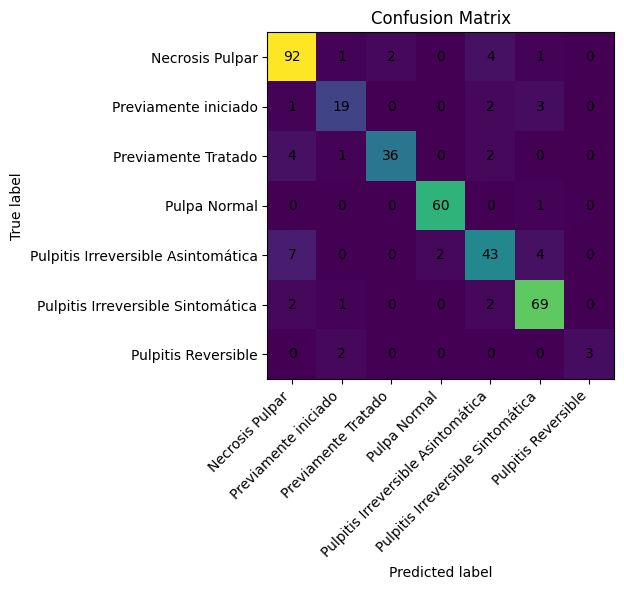

In [22]:
#Evaluation of the new model on the full dataset

exported_program = torch.export.load("Models/DentalDeepGA_transfer_model.pt2")
full_model_pt2 = exported_program.module().to(device)

results_new = evaluate_full_model(
    model=full_model_pt2,
    loader=all_multi_loader,
    device=device,
    idx_to_class=idx_to_class,
)

print("=== Evaluación del modelo nuevo sobre TODO el dataset ===")
print(f"Accuracy           : {results_new['accuracy']:.4f}")
print(f"Precision macro    : {results_new['precision_macro']:.4f}")
print(f"Recall macro       : {results_new['recall_macro']:.4f}")
print(f"F1 macro           : {results_new['f1_macro']:.4f}")
print(f"Precision weighted : {results_new['precision_weighted']:.4f}")
print(f"Recall weighted    : {results_new['recall_weighted']:.4f}")
print(f"F1 weighted        : {results_new['f1_weighted']:.4f}")

print("\nClassification report:\n")
print(results_new["classification_report"])

print("\nConfusion matrix:\n")
print(results_new["confusion_matrix"])

plot_confusion_matrix(results_new["confusion_matrix"], idx_to_class)

In [23]:

def compare_models_side_by_side(results_old, results_new, idx_to_class):
    # =========================
    # 1) Tabla de métricas
    # =========================
    metrics_df = pd.DataFrame({
        "Métrica": [
            "Accuracy",
            "Precision macro",
            "Recall macro",
            "F1 macro",
            "Precision weighted",
            "Recall weighted",
            "F1 weighted",
        ],
        "Modelo anterior": [
            results_old["accuracy"],
            results_old["precision_macro"],
            results_old["recall_macro"],
            results_old["f1_macro"],
            results_old["precision_weighted"],
            results_old["recall_weighted"],
            results_old["f1_weighted"],
        ],
        "Modelo nuevo": [
            results_new["accuracy"],
            results_new["precision_macro"],
            results_new["recall_macro"],
            results_new["f1_macro"],
            results_new["precision_weighted"],
            results_new["recall_weighted"],
            results_new["f1_weighted"],
        ],
    })

    metrics_df["Modelo anterior"] = metrics_df["Modelo anterior"].map(lambda x: f"{x:.4f}")
    metrics_df["Modelo nuevo"] = metrics_df["Modelo nuevo"].map(lambda x: f"{x:.4f}")

    print("=== Comparación de métricas ===")
    print(metrics_df.to_string(index=False))

    # =========================
    # 2) Matrices lado a lado
    # =========================
    cm_old = results_old["confusion_matrix"]
    cm_new = results_new["confusion_matrix"]

    labels = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Matriz modelo anterior
    ax = axes[0]
    im0 = ax.imshow(cm_old)
    ax.set_title("Modelo anterior")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm_old.shape[0]):
        for j in range(cm_old.shape[1]):
            ax.text(j, i, str(cm_old[i, j]), ha="center", va="center")

    # Matriz modelo nuevo
    ax = axes[1]
    im1 = ax.imshow(cm_new)
    ax.set_title("Modelo nuevo")
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

    for i in range(cm_new.shape[0]):
        for j in range(cm_new.shape[1]):
            ax.text(j, i, str(cm_new[i, j]), ha="center", va="center")

    plt.tight_layout()
    plt.show()

    # =========================
    # 3) Reports completos
    # =========================
    print("\n=== Classification report: Modelo anterior ===\n")
    print(results_old["classification_report"])

    print("\n=== Classification report: Modelo nuevo ===\n")
    print(results_new["classification_report"])

=== Comparación de métricas ===
           Métrica Modelo anterior Modelo nuevo
          Accuracy          0.3388       0.8846
   Precision macro          0.1658       0.8958
      Recall macro          0.2220       0.8287
          F1 macro          0.1666       0.8543
Precision weighted          0.2354       0.8853
   Recall weighted          0.3388       0.8846
       F1 weighted          0.2477       0.8834


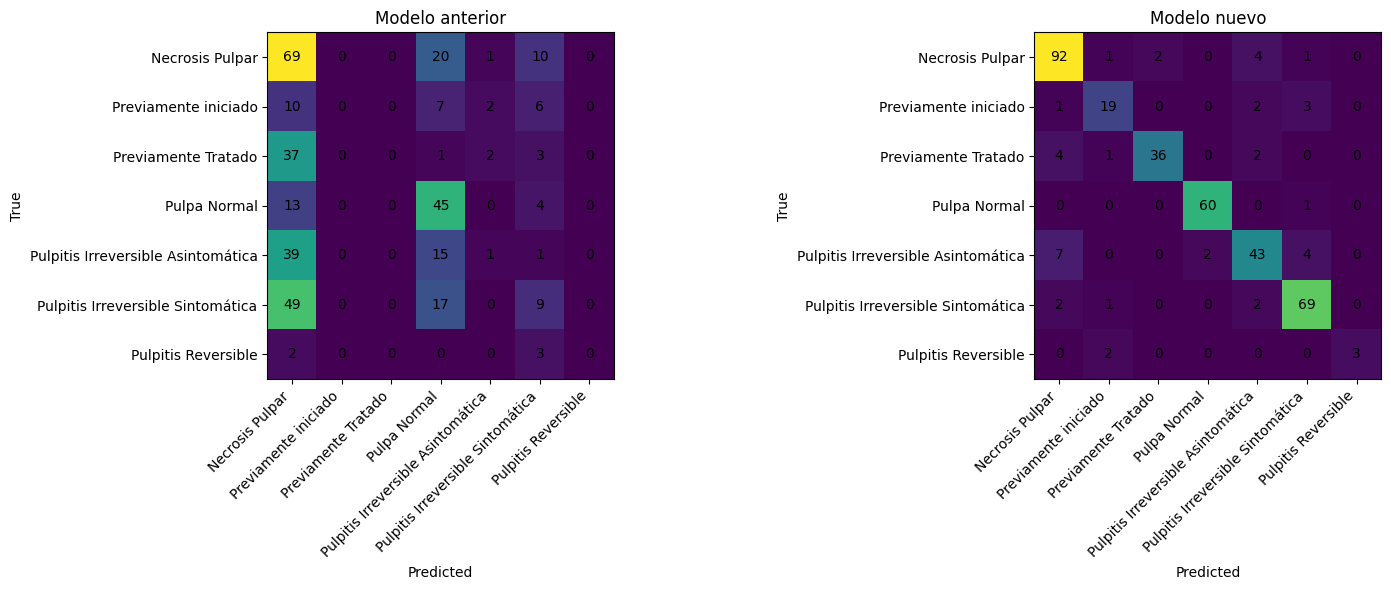


=== Classification report: Modelo anterior ===

                                    precision    recall  f1-score   support

                   Necrosis Pulpar       0.32      0.69      0.43       100
              Previamente iniciado       0.00      0.00      0.00        25
               Previamente tratado       0.00      0.00      0.00        43
                      Pulpa Normal       0.43      0.73      0.54        62
Pulpitis irreversible asintomatica       0.17      0.02      0.03        56
 Pulpitis irreversible sintomatica       0.25      0.12      0.16        75
               Pulpitis reversible       0.00      0.00      0.00         5

                          accuracy                           0.34       366
                         macro avg       0.17      0.22      0.17       366
                      weighted avg       0.24      0.34      0.25       366


=== Classification report: Modelo nuevo ===

                                    precision    recall  f1-score 

In [24]:
compare_models_side_by_side(results_old, results_new, idx_to_class)

# Testing the old model:

In [25]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

def build_full_loader_like_notebook(
    data_dir,
    image_size=128,
    batch_size=32,
    num_workers=2,
):
    eval_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    ds_eval = datasets.ImageFolder(root=data_dir, transform=eval_transform)

    pin = torch.cuda.is_available()

    full_dl = DataLoader(
        ds_eval,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin
    )

    return {
        "full_dl": full_dl,
        "ds_eval": ds_eval,
        "class_names": ds_eval.classes,
        "class_to_idx": ds_eval.class_to_idx,
        "n_channels": 1,
        "n_classes": len(ds_eval.classes),
        "out_size": image_size,
    }

In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

def test_model_on_full_dataset(
    model,
    data_dir,
    device,
    image_size=128,
    batch_size=32,
    num_workers=2,
    show_confusion_matrix=True,
):
    loader_info = build_full_loader_like_notebook(
        data_dir=data_dir,
        image_size=image_size,
        batch_size=batch_size,
        num_workers=num_workers,
    )

    full_dl = loader_info["full_dl"]
    class_names = loader_info["class_names"]

    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in full_dl:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)

    print("=== RESULTADOS EN TODO EL DATASET ===")
    print(f"Accuracy: {acc:.4f}\n")

    print("=== class_names ===")
    print(class_names)
    print()

    print("=== class_to_idx ===")
    print(loader_info["class_to_idx"])
    print()

    print("=== total de imágenes ===")
    print(len(loader_info["ds_eval"]))
    print()

    print("=== CLASIFICACIÓN POR CLASE ===")
    print(classification_report(
        all_labels,
        all_preds,
        labels=list(range(len(class_names))),
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(len(class_names)))
    )

    print("=== MATRIZ DE CONFUSIÓN ===")
    print(cm)

    if show_confusion_matrix:
        plt.figure(figsize=(8, 8))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )
        disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
        plt.title("Matriz de confusión - Dataset completo")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc,
        "y_true": all_labels,
        "y_pred": all_preds,
        "confusion_matrix": cm,
        "class_names": class_names,
        "class_to_idx": loader_info["class_to_idx"],
        "full_dl": full_dl,
    }

=== RESULTADOS EN TODO EL DATASET ===
Accuracy: 0.8552

=== class_names ===
['Necrosis Pulpar', 'Previamente iniciado', 'Previamente tratado', 'Pulpa Normal', 'Pulpitis irreversible asintomatica', 'Pulpitis irreversible sintomatica', 'Pulpitis reversible']

=== class_to_idx ===
{'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente tratado': 2, 'Pulpa Normal': 3, 'Pulpitis irreversible asintomatica': 4, 'Pulpitis irreversible sintomatica': 5, 'Pulpitis reversible': 6}

=== total de imágenes ===
366

=== CLASIFICACIÓN POR CLASE ===
                                    precision    recall  f1-score   support

                   Necrosis Pulpar     0.9222    0.8300    0.8737       100
              Previamente iniciado     0.8500    0.6800    0.7556        25
               Previamente tratado     0.8372    0.8372    0.8372        43
                      Pulpa Normal     0.9833    0.9516    0.9672        62
Pulpitis irreversible asintomatica     0.7059    0.8571    0.7742        5

<Figure size 800x800 with 0 Axes>

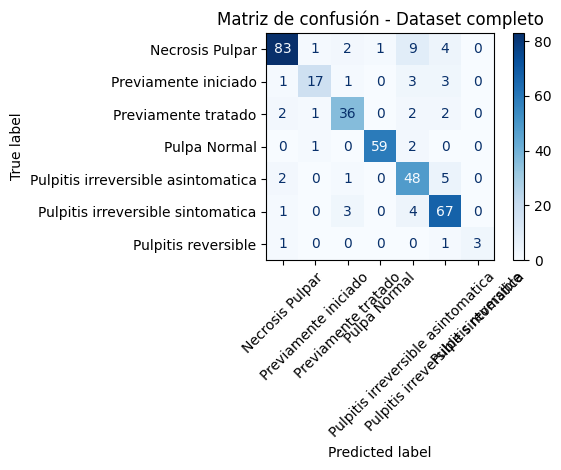

In [27]:
results_test = test_model_on_full_dataset(
    model=simple_model,
    data_dir=str("DataSet/radiografia_dataset_original"),   # o "DataSet/radiografia_dataset_original"
    device=device,
    image_size=128,
    batch_size=32,

    num_workers=2,
    show_confusion_matrix=True,
)

# Only test data

In [28]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import StratifiedShuffleSplit

def build_test_loader_like_notebook(
    data_dir,
    image_size=128,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=2,
):
    eval_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])

    ds_base = datasets.ImageFolder(root=data_dir, transform=None)
    y = np.array(ds_base.targets)
    idx = np.arange(len(ds_base))

    # Split estratificado: (train+val) vs test
    sss_test = StratifiedShuffleSplit(
        n_splits=1,
        test_size=test_split,
        random_state=seed
    )
    trainval_idx, test_idx = next(sss_test.split(idx, y))

    # Split estratificado: train vs val
    y_trainval = y[trainval_idx]
    val_rel = val_split / (1.0 - test_split)

    sss_val = StratifiedShuffleSplit(
        n_splits=1,
        test_size=val_rel,
        random_state=seed
    )
    train_rel, val_rel_idx = next(sss_val.split(trainval_idx, y_trainval))

    train_idx = trainval_idx[train_rel]
    val_idx = trainval_idx[val_rel_idx]

    ds_eval = datasets.ImageFolder(root=data_dir, transform=eval_transform)

    pin = torch.cuda.is_available()

    test_dl = DataLoader(
        Subset(ds_eval, test_idx),
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin
    )

    return {
        "test_dl": test_dl,
        "ds_eval": ds_eval,
        "train_idx": train_idx,
        "val_idx": val_idx,
        "test_idx": test_idx,
        "class_names": ds_eval.classes,
        "class_to_idx": ds_eval.class_to_idx,
        "n_channels": 1,
        "n_classes": len(ds_eval.classes),
        "out_size": image_size,
    }

In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
)

def test_model_with_internal_loader(
    model,
    data_dir,
    device,
    image_size=128,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=2,
    show_confusion_matrix=True,
):
    # -------------------------------------------------
    # 1) construir loader igual que en el notebook
    # -------------------------------------------------
    loader_info = build_test_loader_like_notebook(
        data_dir=data_dir,
        image_size=image_size,
        batch_size=batch_size,
        val_split=val_split,
        test_split=test_split,
        seed=seed,
        num_workers=num_workers,
    )

    test_dl = loader_info["test_dl"]
    class_names = loader_info["class_names"]

    # -------------------------------------------------
    # 2) evaluación
    # -------------------------------------------------
    model = model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_dl:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)

    print("=== RESULTADOS EN TEST ===")
    print(f"Accuracy: {acc:.4f}\n")

    print("=== class_names ===")
    print(class_names)
    print()

    print("=== class_to_idx ===")
    print(loader_info["class_to_idx"])
    print()

    print("=== tamaño del split test ===")
    print(len(loader_info["test_idx"]))
    print()

    print("=== CLASIFICACIÓN POR CLASE ===")
    print(classification_report(
        all_labels,
        all_preds,
        labels=list(range(len(class_names))),
        target_names=class_names,
        digits=4,
        zero_division=0
    ))

    cm = confusion_matrix(
        all_labels,
        all_preds,
        labels=list(range(len(class_names)))
    )

    print("=== MATRIZ DE CONFUSIÓN ===")
    print(cm)

    if show_confusion_matrix:
        plt.figure(figsize=(8, 8))
        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=class_names
        )
        disp.plot(cmap="Blues", xticks_rotation=45, values_format="d")
        plt.title("Matriz de confusión - Test")
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc,
        "y_true": all_labels,
        "y_pred": all_preds,
        "confusion_matrix": cm,
        "class_names": class_names,
        "class_to_idx": loader_info["class_to_idx"],
        "test_idx": loader_info["test_idx"],
        "test_dl": test_dl,
    }

=== RESULTADOS EN TEST ===
Accuracy: 0.5273

=== class_names ===
['Necrosis Pulpar', 'Previamente iniciado', 'Previamente tratado', 'Pulpa Normal', 'Pulpitis irreversible asintomatica', 'Pulpitis irreversible sintomatica', 'Pulpitis reversible']

=== class_to_idx ===
{'Necrosis Pulpar': 0, 'Previamente iniciado': 1, 'Previamente tratado': 2, 'Pulpa Normal': 3, 'Pulpitis irreversible asintomatica': 4, 'Pulpitis irreversible sintomatica': 5, 'Pulpitis reversible': 6}

=== tamaño del split test ===
55

=== CLASIFICACIÓN POR CLASE ===
                                    precision    recall  f1-score   support

                   Necrosis Pulpar     0.7778    0.4667    0.5833        15
              Previamente iniciado     0.0000    0.0000    0.0000         4
               Previamente tratado     0.4444    0.5714    0.5000         7
                      Pulpa Normal     1.0000    0.8889    0.9412         9
Pulpitis irreversible asintomatica     0.2857    0.5000    0.3636         8
 Pulpi

<Figure size 800x800 with 0 Axes>

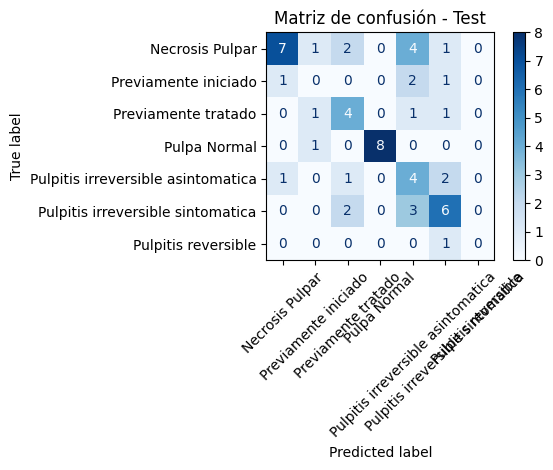

In [30]:
results_test = test_model_with_internal_loader(
    model=simple_model,
    data_dir=str("DataSet/radiografia_dataset_original"),   # o "DataSet/radiografia_dataset_original"
    device=device,
    image_size=128,
    batch_size=32,
    val_split=0.15,
    test_split=0.15,
    seed=42,
    num_workers=2,
    show_confusion_matrix=True,
)